<div class="alert alert-block alert-info" style="padding:20px;color:white;margin:auto;font-size:300%;text-align:center;display:fill;border-radius:60px;background-color:#37006f;overflow:hidden;font-weight:800">Time Series Forecasting</div>

**Description:** In this notebook we investigate the different available approaches in Kraken for time series analysis using the AAPL dataset.

In [1]:
cd ..

d:\Personal Projects\kraken


d:\Personal Projects\kraken\.venv\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


## 1. BiLSTM

### 1.1 Model Training

In [ ]:
from kraken.models.time_series import BiLSTMPredictor

predictor = BiLSTMPredictor(
    window_size=24,
    data_path="./datasets/AAPL.csv",
    target_column="Close"
)

predictor()

Epoch 1/50
260/260 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0284 - mae: 0.0681 - val_loss: 4.9049 - val_mae: 1.2523
Epoch 2/50
260/260 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0283 - mae: 0.0669 - val_loss: 4.8968 - val_mae: 1.2510
Epoch 3/50
260/260 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0282 - mae: 0.0666 - val_loss: 4.8972 - val_mae: 1.2509
Epoch 4/50
260/260 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0282 - mae: 0.0666 - val_loss: 4.8955 - val_mae: 1.2507
Epoch 5/50
260/260 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0281 - mae: 0.0656 - val_loss: 4.8959 - val_mae: 1.2510
Epoch 6/50
260/260 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0281 - mae: 0.0653 - val_loss: 4.8883 - val_mae: 1.2507
Epoch 7/50
260/260 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0281 - mae: 0.0652 - val_loss: 4.8915 - val_mae: 1.2505
Epoch 8/50
260/260 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0281 - mae: 0.0653 - val_loss: 4.8914 - val_mae: 1.2508
Epoch 9/50
260/260 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - 

### 1.2 Model Prediction

In [4]:
predictor.predict(n_steps=5)

[np.float64(174.22080701950264),
 np.float64(174.359951678545),
 np.float64(174.4547332635827),
 np.float64(174.70135072979403),
 np.float64(174.86118188116026)]

### 1.3 Visualization

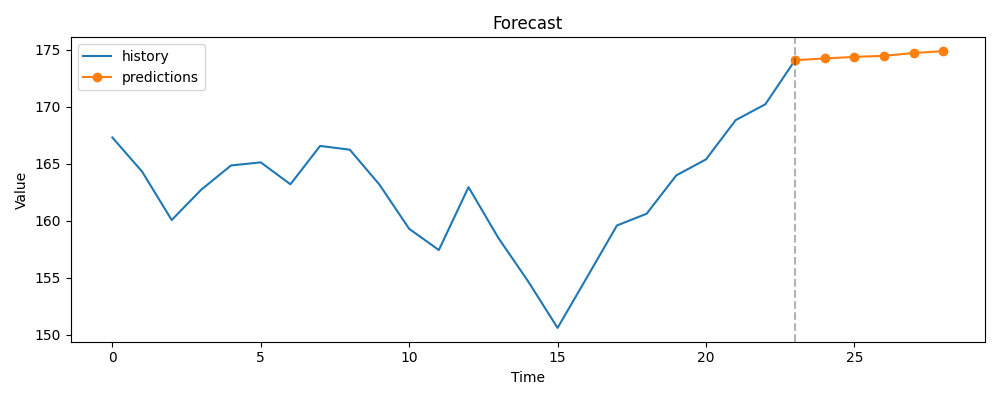

In [ ]:
# Prepare history and predictions
from kraken.utils.visualization import plot_series_with_predictions
from IPython.display import Image, display

# Load the original series and take the last `window_size` points as history
series = predictor.load_data(predictor.data_path, predictor.target_column)[0]
history = series[-predictor.window_size:]

# Generate predictions
preds = predictor.predict(n_steps=5)

# Save plot to file
plot_series_with_predictions(history, preds, title='Forecast', save_path='forecast_plot.png', show=False)

# Display the saved image
display(Image('forecast_plot.png'))

# 2. LSTM with Attention

## 2.1 Model Training

In [2]:
from kraken.models.time_series import LSTMAttentionPredictor

predictor = LSTMAttentionPredictor(
    lstm_units=128,
    window_size=24,
    data_path="./datasets/AAPL.csv",
    target_column="Close"
)

predictor()

Epoch 1/50
260/260 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0281 - mae: 0.0655 - val_loss: 4.9051 - val_mae: 1.2510
Epoch 2/50
260/260 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0280 - mae: 0.0644 - val_loss: 4.9053 - val_mae: 1.2507
Epoch 3/50
260/260 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0280 - mae: 0.0642 - val_loss: 4.9057 - val_mae: 1.2506
Epoch 4/50
260/260 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0280 - mae: 0.0641 - val_loss: 4.9061 - val_mae: 1.2506
Epoch 5/50
260/260 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0280 - mae: 0.0641 - val_loss: 4.9063 - val_mae: 1.2506
Epoch 6/50
260/260 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0280 - mae: 0.0640 - val_loss: 4.9066 - val_mae: 1.2505
Epoch 7/50
260/260 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0280 - mae: 0.0640 - val_loss: 4.9068 - val_mae: 1.2505
Epoch 8/50
260/260 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0280 - mae: 0.0640 - val_loss: 4.9070 - val_mae: 1.2505
Epoch 9/50
260/260 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/s

### 2.2 Model Prediction

In [4]:
predictor.predict(n_steps=5)

[np.float64(174.04607980686498),
 np.float64(174.0306497177787),
 np.float64(174.02550143503842),
 np.float64(174.03598516841677),
 np.float64(174.04345170117242)]

### 2.3 Visualization

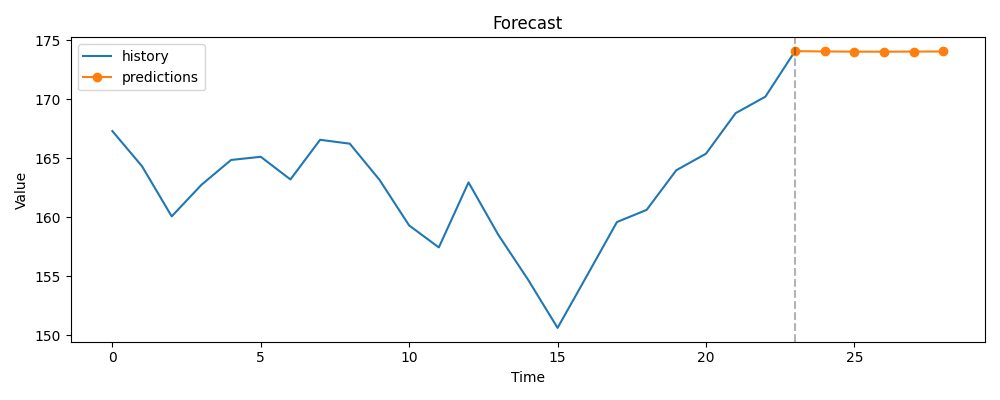

In [3]:
# Prepare history and predictions
from kraken.utils.visualization import plot_series_with_predictions
from IPython.display import Image, display

# Load the original series and take the last `window_size` points as history
series = predictor.load_data(predictor.data_path, predictor.target_column)[0]
history = series[-predictor.window_size:]

# Generate predictions
preds = predictor.predict(n_steps=5)

# Save plot to file
plot_series_with_predictions(history, preds, title='Forecast', save_path='forecast_plot.png', show=False)

# Display the saved image
display(Image('forecast_plot.png'))

# 3. CNN